In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import json
import os
import glob
from matplotlib.ticker import FuncFormatter

# Giữ nguyên các import thuật toán của bạn
import ex1_parametric
import ex2_over_conditioning
import ex3_data_splitting
import ex4_naive
import ex5_cort_without_inference
import ex6_bonferroni


In [5]:
# Đặt giới hạn số luồng xử lý cho mỗi thư viện tính toán về 1
os.environ["OMP_NUM_THREADS"] = "3"
os.environ["MKL_NUM_THREADS"] = "3"
os.environ["OPENBLAS_NUM_THREADS"] = "3"
os.environ["VECLIB_MAXIMUM_THREADS"] = "3"
os.environ["NUMEXPR_NUM_THREADS"] = "3"

🚀 Bắt đầu chạy thuật toán với Signal List = [0.25, 0.5, 0.75, 1.0], n_target = 50...

--- Processing Signal Strength = 0.25 ---
Running DS
Iteration 0
Iteration 50
Iteration 100
Iteration 150
Iteration 200
Iteration 250
Iteration 300
Iteration 350
Iteration 400
Iteration 450
Iteration 500
Iteration 550
Iteration 600
Iteration 650
Iteration 700
Iteration 750
Iteration 800
Iteration 850
Iteration 900
Iteration 950
Done ------> (FPR: 0.049, TPR: 0.141)
Running Bonferroni
Iteration 0
Iteration 50
Iteration 100
Iteration 150
Iteration 200
Iteration 250
Iteration 300
Iteration 350
Iteration 400
Iteration 450
Iteration 500
Iteration 550
Iteration 600
Iteration 650
Iteration 700
Iteration 750
Iteration 800
Iteration 850
Iteration 900
Iteration 950
Done ------> (FPR: 0.000, TPR: 0.035)
Running Naive
Iteration 0
Iteration 50
Iteration 100
Iteration 150
Iteration 200
Iteration 250
Iteration 300
Iteration 350
Iteration 400
Iteration 450
Iteration 500
Iteration 550
Iteration 600
Iteration 650
Itera

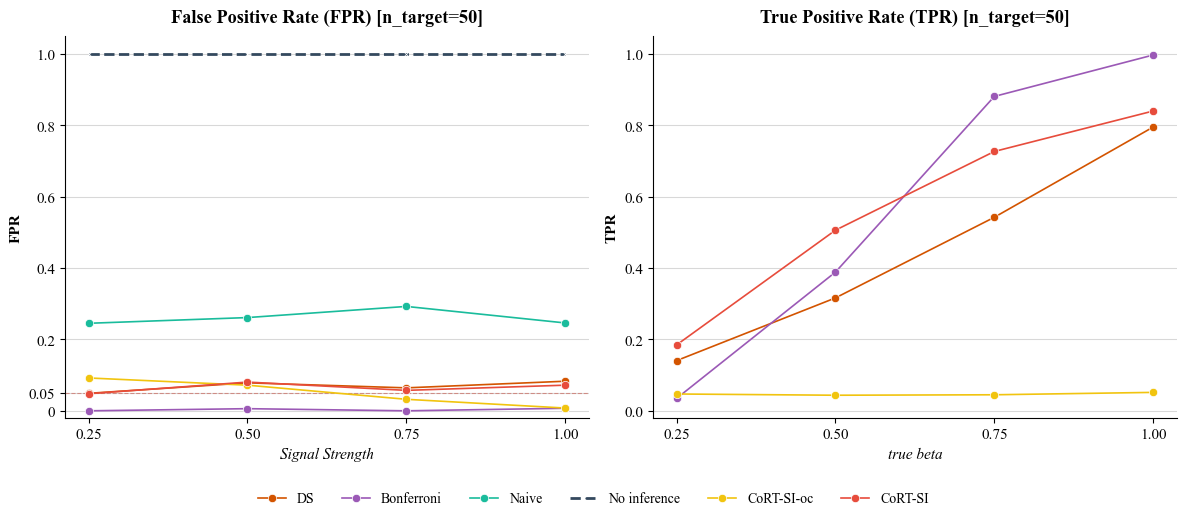

In [ ]:
# ==========================================\n
# PHẦN 1: CẤU HÌNH CHUNG\n
# ==========================================\n
iteration = 1000  # Số lần lặp
n_source = 80
p = 200
K = 5
Ka = 2
h = 10
alpha = 0.05
T = 5

# Cấu hình cố định cho thí nghiệm theo Signal
n_target_fixed = 50  # Cố định n_target (khớp với file JSON của bạn)
s_len = 10           # Độ dài vector signal (khớp với file JSON signal_2,3,4)

# Danh sách Signal Strength cần chạy (Trục hoành)
signal_list = [0.25, 0.5, 0.75, 1.0]

# Định nghĩa các phương pháp
methods = {
    "DS":           {"func": ex3_data_splitting.data_splitting,       "color": "#d35400", "marker": "o", "ls": "-", "lw": 1.2, "zorder": 3},
    "Bonferroni":   {"func": ex6_bonferroni.bonferroni,               "color": "#9b59b6", "marker": "o", "ls": "-", "lw": 1.2, "zorder": 3},
    "Naive":        {"func": ex4_naive.naive,                         "color": "#1abc9c", "marker": "o", "ls": "-", "lw": 1.2, "zorder": 3},
    "No inference": {"func": ex5_cort_without_inference.cort_without_inference, "color": "#34495e", "marker": "x", "ls": "--","lw": 2.0, "zorder": 2},
    "CoRT-SI-oc":   {"func": ex2_over_conditioning.over_conditioning, "color": "#f1c40f", "marker": "o", "ls": "-", "lw": 1.2, "zorder": 3},
    # CoRT-SI load từ file
    "CoRT-SI":      {"func": None,                                    "color": "#e74c3c", "marker": "o", "ls": "-", "lw": 1.2, "zorder": 3}
}

experiment_results = {name: {"fpr": [], "tpr": []} for name in methods}

# ==========================================\n
# PHẦN 2: CHẠY 5 THUẬT TOÁN NHANH THEO SIGNAL
# ==========================================\n
print(f"🚀 Bắt đầu chạy thuật toán với Signal List = {signal_list}, n_target = {n_target_fixed}...")

for s_val in signal_list:
    print(f"\n--- Processing Signal Strength = {s_val} ---")
    
    # Tạo s_vector dựa trên signal hiện tại
    current_s_vector = [s_val] * s_len
    
    for name, config in methods.items():
        if name == "CoRT-SI": continue
            
        print(f"Running {name}")
        # Gọi hàm với tham số hiện tại
        curr_fpr, curr_tpr = config["func"](
            iteration, n_target_fixed, n_source, p, K, Ka, h, alpha, T, s_len, current_s_vector
        )
        experiment_results[name]["fpr"].append(curr_fpr)
        experiment_results[name]["tpr"].append(curr_tpr)
        print(f"Done ------> (FPR: {curr_fpr:.3f}, TPR: {curr_tpr:.3f})")

# ==========================================\n
# PHẦN 3: LOAD KẾT QUẢ CoRT-SI VÀ GOM NHÓM THEO SIGNAL
# ==========================================\n
print("\n📂 Đang xử lý dữ liệu CoRT-SI từ thư mục 'records/' theo Signal...")

def load_cort_si_by_signal(target_signal_list, filter_s_len, filter_n_target):
    folder_path = 'records_2/' 
    file_pattern = os.path.join(folder_path, '*.json')
    list_files = glob.glob(file_pattern)
    
    if not list_files:
        print("❌ Không tìm thấy file JSON!")
        return [0]*len(target_signal_list), [0]*len(target_signal_list)

    all_dataframes = []
    for filename in list_files:
        try:
            with open(filename, 'r') as f:
                data = json.load(f)
                if data:
                    df = pd.json_normalize(data)
                    # Trích xuất giá trị signal đầu tiên từ vector
                    df['extracted_signal'] = df['configs.s_vector'].apply(
                        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else 0
                    )
                    all_dataframes.append(df)
        except Exception as e:
            print(f"⚠️ Lỗi đọc file {filename}: {e}")

    if not all_dataframes:
        return [0]*len(target_signal_list), [0]*len(target_signal_list)

    big_df = pd.concat(all_dataframes, ignore_index=True)
    
    # LỌC DỮ LIỆU: Chỉ lấy các dòng khớp với cấu hình s_len và n_target hiện tại
    # Để tránh trộn lẫn các thí nghiệm khác nhau (ví dụ file signal_1 có s_len=5)
    mask = (big_df['configs.s_len'] == filter_s_len) & (big_df['configs.n_target'] == filter_n_target)
    filtered_df = big_df[mask].copy()
    
    print(f"   Đã lọc dữ liệu: Giữ lại {len(filtered_df)}/{len(big_df)} bản ghi khớp với s_len={filter_s_len}, n_target={filter_n_target}")

    # Gom nhóm theo signal
    cols_to_sum = ['is_signal_cases', 'not_signal_cases', 'true_positives', 'false_positives']
    filtered_df[cols_to_sum] = filtered_df[cols_to_sum].fillna(0)
    grouped = filtered_df.groupby('extracted_signal')[cols_to_sum].sum()
    
    final_fprs = []
    final_tprs = []
    
    print(f"   Tìm thấy dữ liệu cho Signal: {grouped.index.tolist()}")
    
    for sig in target_signal_list:
        # Dùng np.isclose để so sánh số thực float cho chính xác
        match = grouped.index[np.isclose(grouped.index, sig, atol=1e-9)]
        
        if not match.empty:
            row = grouped.loc[match[0]]
            # Tính FPR
            fpr = row['false_positives'] / row['not_signal_cases'] if row['not_signal_cases'] > 0 else 0.0
            # Tính TPR
            tpr = row['true_positives'] / row['is_signal_cases'] if row['is_signal_cases'] > 0 else 0.0
            
            final_fprs.append(fpr)
            final_tprs.append(tpr)
        else:
            print(f"⚠️ Cảnh báo: Không có dữ liệu CoRT-SI cho signal={sig}. Gán bằng 0.")
            final_fprs.append(0.0)
            final_tprs.append(0.0)
            
    return final_fprs, final_tprs

# Gọi hàm load dữ liệu
cort_fpr, cort_tpr = load_cort_si_by_signal(signal_list, s_len, n_target_fixed)
experiment_results["CoRT-SI"]["fpr"] = cort_fpr
experiment_results["CoRT-SI"]["tpr"] = cort_tpr
print(f"✅ Đã nạp CoRT-SI theo Signal: FPR={cort_fpr}, TPR={cort_tpr}")

# ==========================================\n
# PHẦN 4: VẼ BIỂU ĐỒ (VISUALIZATION)
# ==========================================\n
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 11
plt.rcParams['axes.linewidth'] = 0.8

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

def format_func(value, tick_number):
    if abs(value - alpha) < 1e-9: return f'{alpha}'
    if value == 0.0: return '0'
    return f'{value:.1f}'

# === 1. BIỂU ĐỒ FPR ===
ax1.axhline(y=alpha, color='#e74c3c', linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)

for name, data in experiment_results.items():
    cfg = methods[name]
    ax1.plot(signal_list, data["fpr"], 
             label=name, 
             color=cfg["color"], 
             linestyle=cfg["ls"],
             marker=cfg["marker"], 
             markersize=6,      
             linewidth=cfg.get("lw", 1.2),     
             markeredgecolor='white', 
             markeredgewidth=0.5,
             zorder=cfg.get("zorder", 3)) 

# Tinh chỉnh trục FPR
standard_ticks = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
fpr_ticks = sorted(list(set(standard_ticks + [alpha])))
ax1.set_yticks(fpr_ticks)
ax1.yaxis.set_major_formatter(FuncFormatter(format_func))
ax1.set_title(f"False Positive Rate (FPR) [n_target={n_target_fixed}]", fontweight='bold', pad=10)
ax1.set_xlabel("true beta", style='italic')
ax1.set_ylabel("FPR", fontweight='bold')
ax1.set_xticks(signal_list)
ax1.set_ylim(-0.02, 1.05)
ax1.grid(axis='y', linestyle='-', alpha=0.3, color='gray', zorder=0)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# === 2. BIỂU ĐỒ TPR ===
for name, data in experiment_results.items():
    if name in ["Naive", "No inference"]: continue
        
    cfg = methods[name]
    ax2.plot(signal_list, data["tpr"], 
             label=name, 
             color=cfg["color"], 
             linestyle=cfg["ls"],
             marker=cfg["marker"],
             markersize=6,
             linewidth=cfg.get("lw", 1.2),
             markeredgecolor='white',
             markeredgewidth=0.5,
             zorder=cfg.get("zorder", 3))

# Tinh chỉnh trục TPR
ax2.set_title(f"True Positive Rate (TPR) [n_target={n_target_fixed}]", fontweight='bold', pad=10)
ax2.set_xlabel("true beta", style='italic')
ax2.set_ylabel("TPR", fontweight='bold')
ax2.set_xticks(signal_list)
ax2.set_yticks(standard_ticks)
ax2.set_ylim(-0.02, 1.05)
ax2.grid(axis='y', linestyle='-', alpha=0.3, color='gray', zorder=0)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- LEGEND CHUNG ---
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, 
           loc='lower center', 
           bbox_to_anchor=(0.5, -0.05), 
           ncol=6, 
           frameon=False, 
           fontsize=10)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15) 
plt.show()